### Import Basic Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [ ]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Check Dataset

In [ ]:
df.info()

df['sentiment'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


sentiment
positive    25000
negative    25000
Name: count, dtype: int64

### Import NLP Libraries

In [ ]:
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

### Download NLTK Data

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\souri
[nltk_data]     krishna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\souri
[nltk_data]     krishna\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### Create Stopwords and Lemmatizer

In [ ]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

### Text Preprocessing Function

In [ ]:
def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words
             if word not in stop_words]

    words = [lemmatizer.lemmatize(word)
             for word in words]

    return " ".join(words)

### Apply Preprocessing

In [ ]:
df['clean_review'] = df['review'].apply(preprocess)

### Check Output

In [ ]:
df[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


### Convert Labels

In [ ]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

### Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## NLP MODEL 1: BAG OF WORDS

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)

X_test_bow = bow.transform(X_test)

## ML MODEL 1: NAIVE BAYES

In [ ]:
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score

nb = MultinomialNB()

nb.fit(X_train_bow, y_train)

pred_nb = nb.predict(X_test_bow)

acc_nb = accuracy_score(
    y_test,
    pred_nb
)

print(acc_nb)

0.8456


## ML MODEL 2: LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_bow, y_train)

pred_lr = lr.predict(X_test_bow)

acc_lr = accuracy_score(
    y_test,
    pred_lr
)

print(acc_lr)

0.8731


## NLP MODEL 2: TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

## TF-IDF + Naive Bayes

In [ ]:
nb_tfidf = MultinomialNB()

nb_tfidf.fit(
    X_train_tfidf,
    y_train
)

pred_nb_tfidf = nb_tfidf.predict(
    X_test_tfidf
)

acc_nb_tfidf = accuracy_score(
    y_test,
    pred_nb_tfidf
)

print(acc_nb_tfidf)

0.8518


## TF-IDF + Logistic Regression

In [ ]:
lr_tfidf = LogisticRegression(max_iter=1000)

lr_tfidf.fit(
    X_train_tfidf,
    y_train
)

pred_lr_tfidf = lr_tfidf.predict(
    X_test_tfidf
)

acc_lr_tfidf = accuracy_score(
    y_test,
    pred_lr_tfidf
)

print(acc_lr_tfidf)

0.8847


### Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    pred_lr_tfidf
))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



### Confusion Matrix

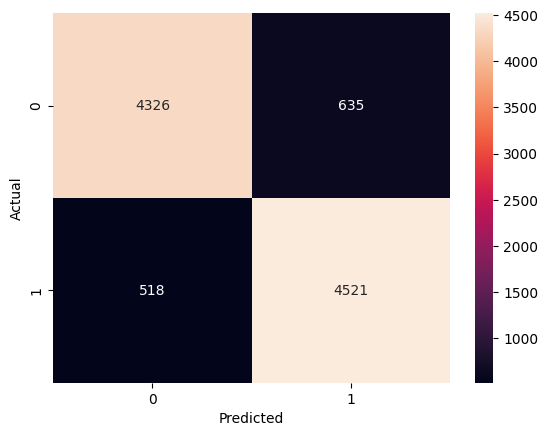

In [ ]:
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    pred_lr_tfidf
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Compare All Models

In [ ]:
results = pd.DataFrame({

    'Model': [

        'BoW + Naive Bayes',

        'BoW + Logistic Regression',

        'TFIDF + Naive Bayes',

        'TFIDF + Logistic Regression'
    ],

    'Accuracy': [

        acc_nb,

        acc_lr,

        acc_nb_tfidf,

        acc_lr_tfidf
    ]
})

results

,Model,Accuracy
0,BoW + Naive Bayes,0.8456
1,BoW + Logistic Regression,0.8731
2,TFIDF + Naive Bayes,0.8518
3,TFIDF + Logistic Regression,0.8847


## Accuracy Graph

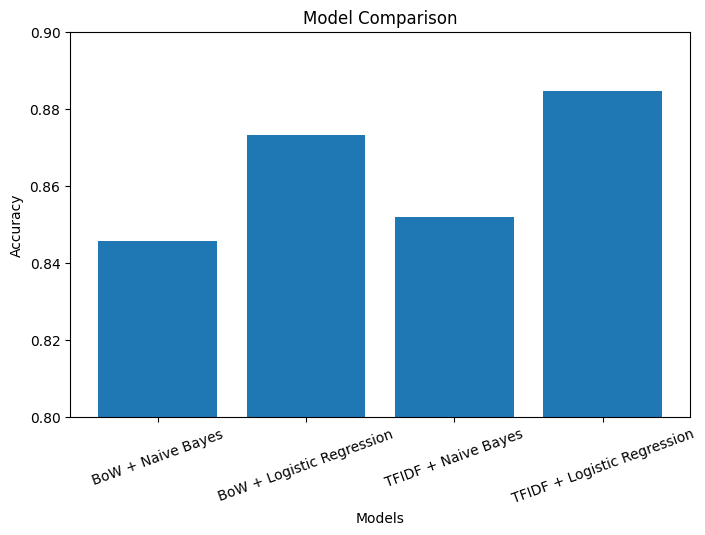

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['Accuracy']
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.ylim(0.80, 0.90)

plt.xticks(rotation=20)

plt.show()

## Conclusion

In [ ]:
best_model = results.loc[
    results['Accuracy'].idxmax()
]

print("Best Model:")

print(best_model)

Best Model:
Model       TFIDF + Logistic Regression
Accuracy                         0.8847
Name: 3, dtype: object
